- Universidad: Universidad de Monterrey
- Fecha: 05/03/2026
- Estudiantes: Jorge Serangelli , Aldo Peña, Jeronimo
- Lugar: Monterrey, Nuevo León
- Docente: Dr. Andrés Hernández Gutiérrez

### **Dataset Selection**

Para este reporte se seleccionó el dataset de "Bank Marketing" de UC Irvine Machine Learning Repository (2014), el cual contiene datos de una campaña de marketing de un banco portugués que contactó clientes por teléfono.

**Dominio de aplicación:** Marketing bancario y predicción de comportamiento del cliente.

**Variables predictivas:** El dataset contiene 16 variables divididas en tres categorías:

- **Información demográfica:** Perfil socioeconómico del cliente que influye en su capacidad para invertir.
  - age: Edad
  - job: Trabajo
  - marital: Estado civil
  - education: Nivel educativo

- **Información financiera:** Situación económica del cliente.
  - balance: Balance anual promedio (euros)
  - default: Tiene deudas impagas
  - housing: Tiene préstamo hipotecario
  - loan: Tiene préstamo personal

- **Información de la campaña:** Historial de contactos con el cliente.
  - contact: Tipo de teléfono usado
  - day_of_week: Día del contacto
  - month: Mes del contacto
  - duration: Duración de la llamada (segundos)
  - campaign: Contactos en esta campaña
  - pdays: Días desde el contacto anterior
  - previous: Contactos en campañas previas
  - poutcome: Resultado de campañas anteriores

**Variable target (y):** Variable binaria que indica si el cliente aceptó suscribirse a un depósito a plazo. Un depósito a plazo es un ahorro donde el cliente deposita dinero por un tiempo acordado y recibe intereses al final. El modelo busca predecir qué clientes tienen mayor probabilidad de aceptar este producto para optimizar los esfuerzos de marketing del banco.

In [1]:
import pandas as pd

columnas = ["age", "job", "marital", "education", "default","balance", 
            "housing", "loan", "contact", "day_of_week" ,"month", "duration", 
            "campaign", "pdays", "previous", "poutcome", "y"]

df = pd.read_csv(
    "bank-full.csv",
    header=0,
    names=columnas,
    sep=";",
    skipinitialspace=True,
    na_values="?"
)

print(df.head())



   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day_of_week month  duration  campaign  pdays  previous poutcome  \
0  unknown            5   may       261         1     -1         0  unknown   
1  unknown            5   may       151         1     -1         0  unknown   
2  unknown            5   may        76         1     -1         0  unknown   
3  unknown            5   may        92         1     -1         0  unknown   
4  unknown            5   may       198         1     -1         0  unknown   

    y  
0  no  
1  no  
2  no  
3  no  
4  no  


Datasets así son comunes en sectores como finanzas, encuestas de gobierno, incluso para investigaciones acádemicas dónde también se realiza encuestas para obtener información de los usuarios para saber si son candidatos a que se le ofrezcan un plan o no, en base a un historia. 

In [2]:
df.shape

(45211, 17)

In [3]:
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

### **Data Cleaning**

In [4]:
df.isna().sum()

age            0
job            0
marital        0
education      0
default        0
balance        0
housing        0
loan           0
contact        0
day_of_week    0
month          0
duration       0
campaign       0
pdays          0
previous       0
poutcome       0
y              0
dtype: int64

In [5]:
df.duplicated(subset=df.columns, keep=False).sum()

np.int64(0)

In [6]:
df.describe()

,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


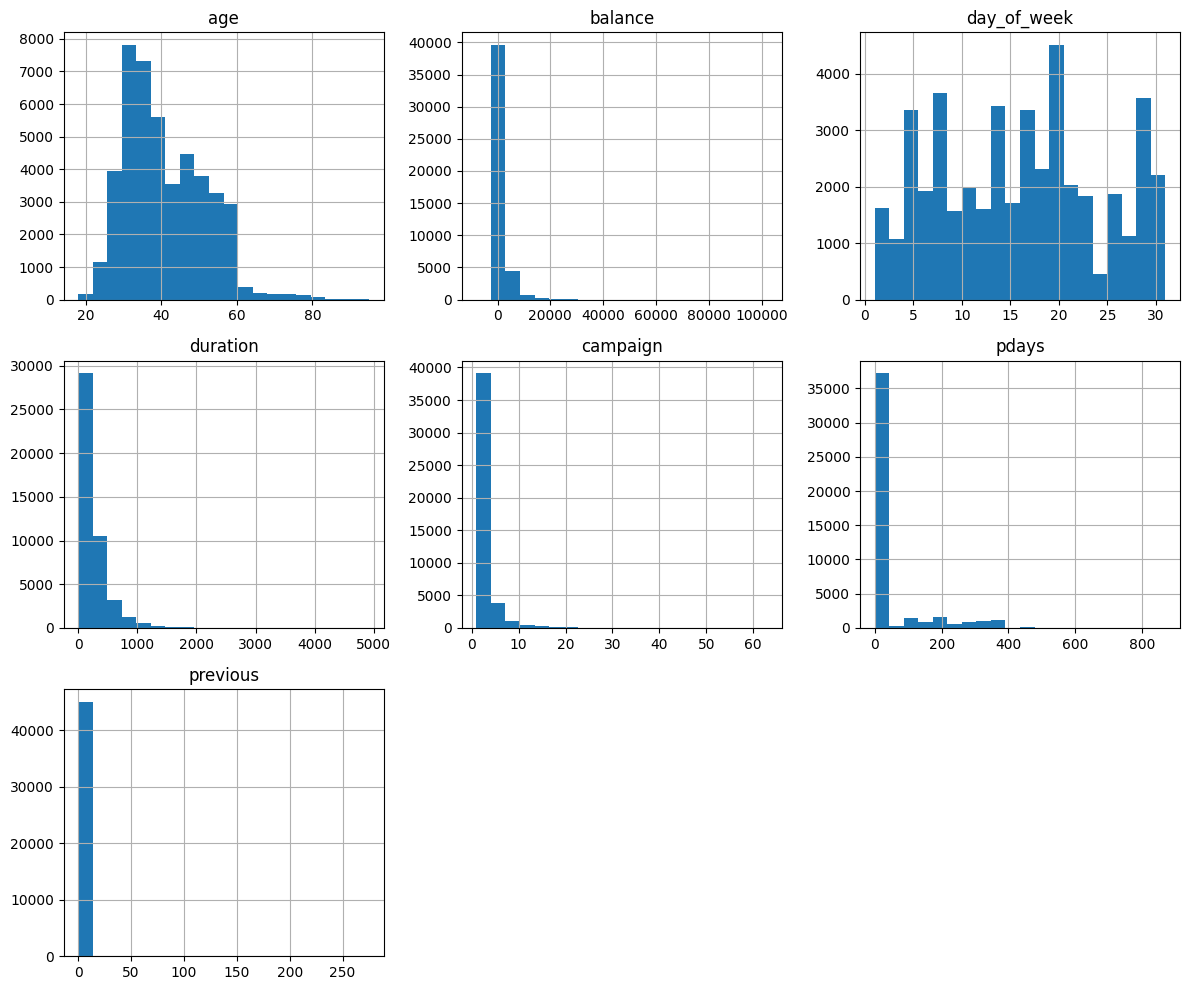

In [7]:
import matplotlib.pyplot as plt
df.hist(figsize=(12, 10),bins=20)
plt.tight_layout()
plt.show()

In [8]:
X = df.drop('y', axis=1)
df['y'] = df['y'].astype('category').cat.codes
y = df['y']
print(X.head())
print(y.head())
print(X.shape)
print(y.shape)

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day_of_week month  duration  campaign  pdays  previous poutcome  
0  unknown            5   may       261         1     -1         0  unknown  
1  unknown            5   may       151         1     -1         0  unknown  
2  unknown            5   may        76         1     -1         0  unknown  
3  unknown            5   may        92         1     -1         0  unknown  
4  unknown            5   may       198         1     -1         0  unknown  
0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int8
(45211, 16)
(45211,)


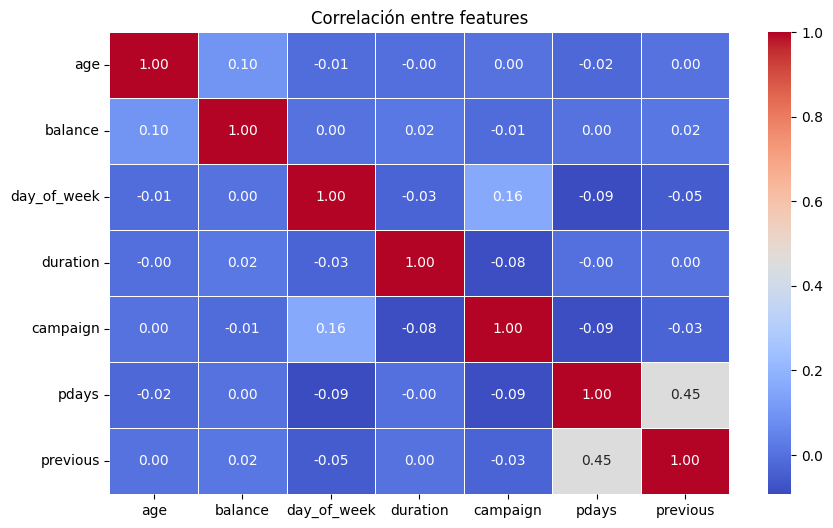

In [9]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.heatmap(X.corr(numeric_only=True),cmap='coolwarm',annot=True, fmt='.2f', linewidths=0.5)
plt.title('Correlación entre features')
plt.show()

In [10]:
# Identificar variables categóricas y numéricas
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['number']).columns.tolist()

# Aplicar one-hot encoding SOLO a las categóricas
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
X = X_encoded

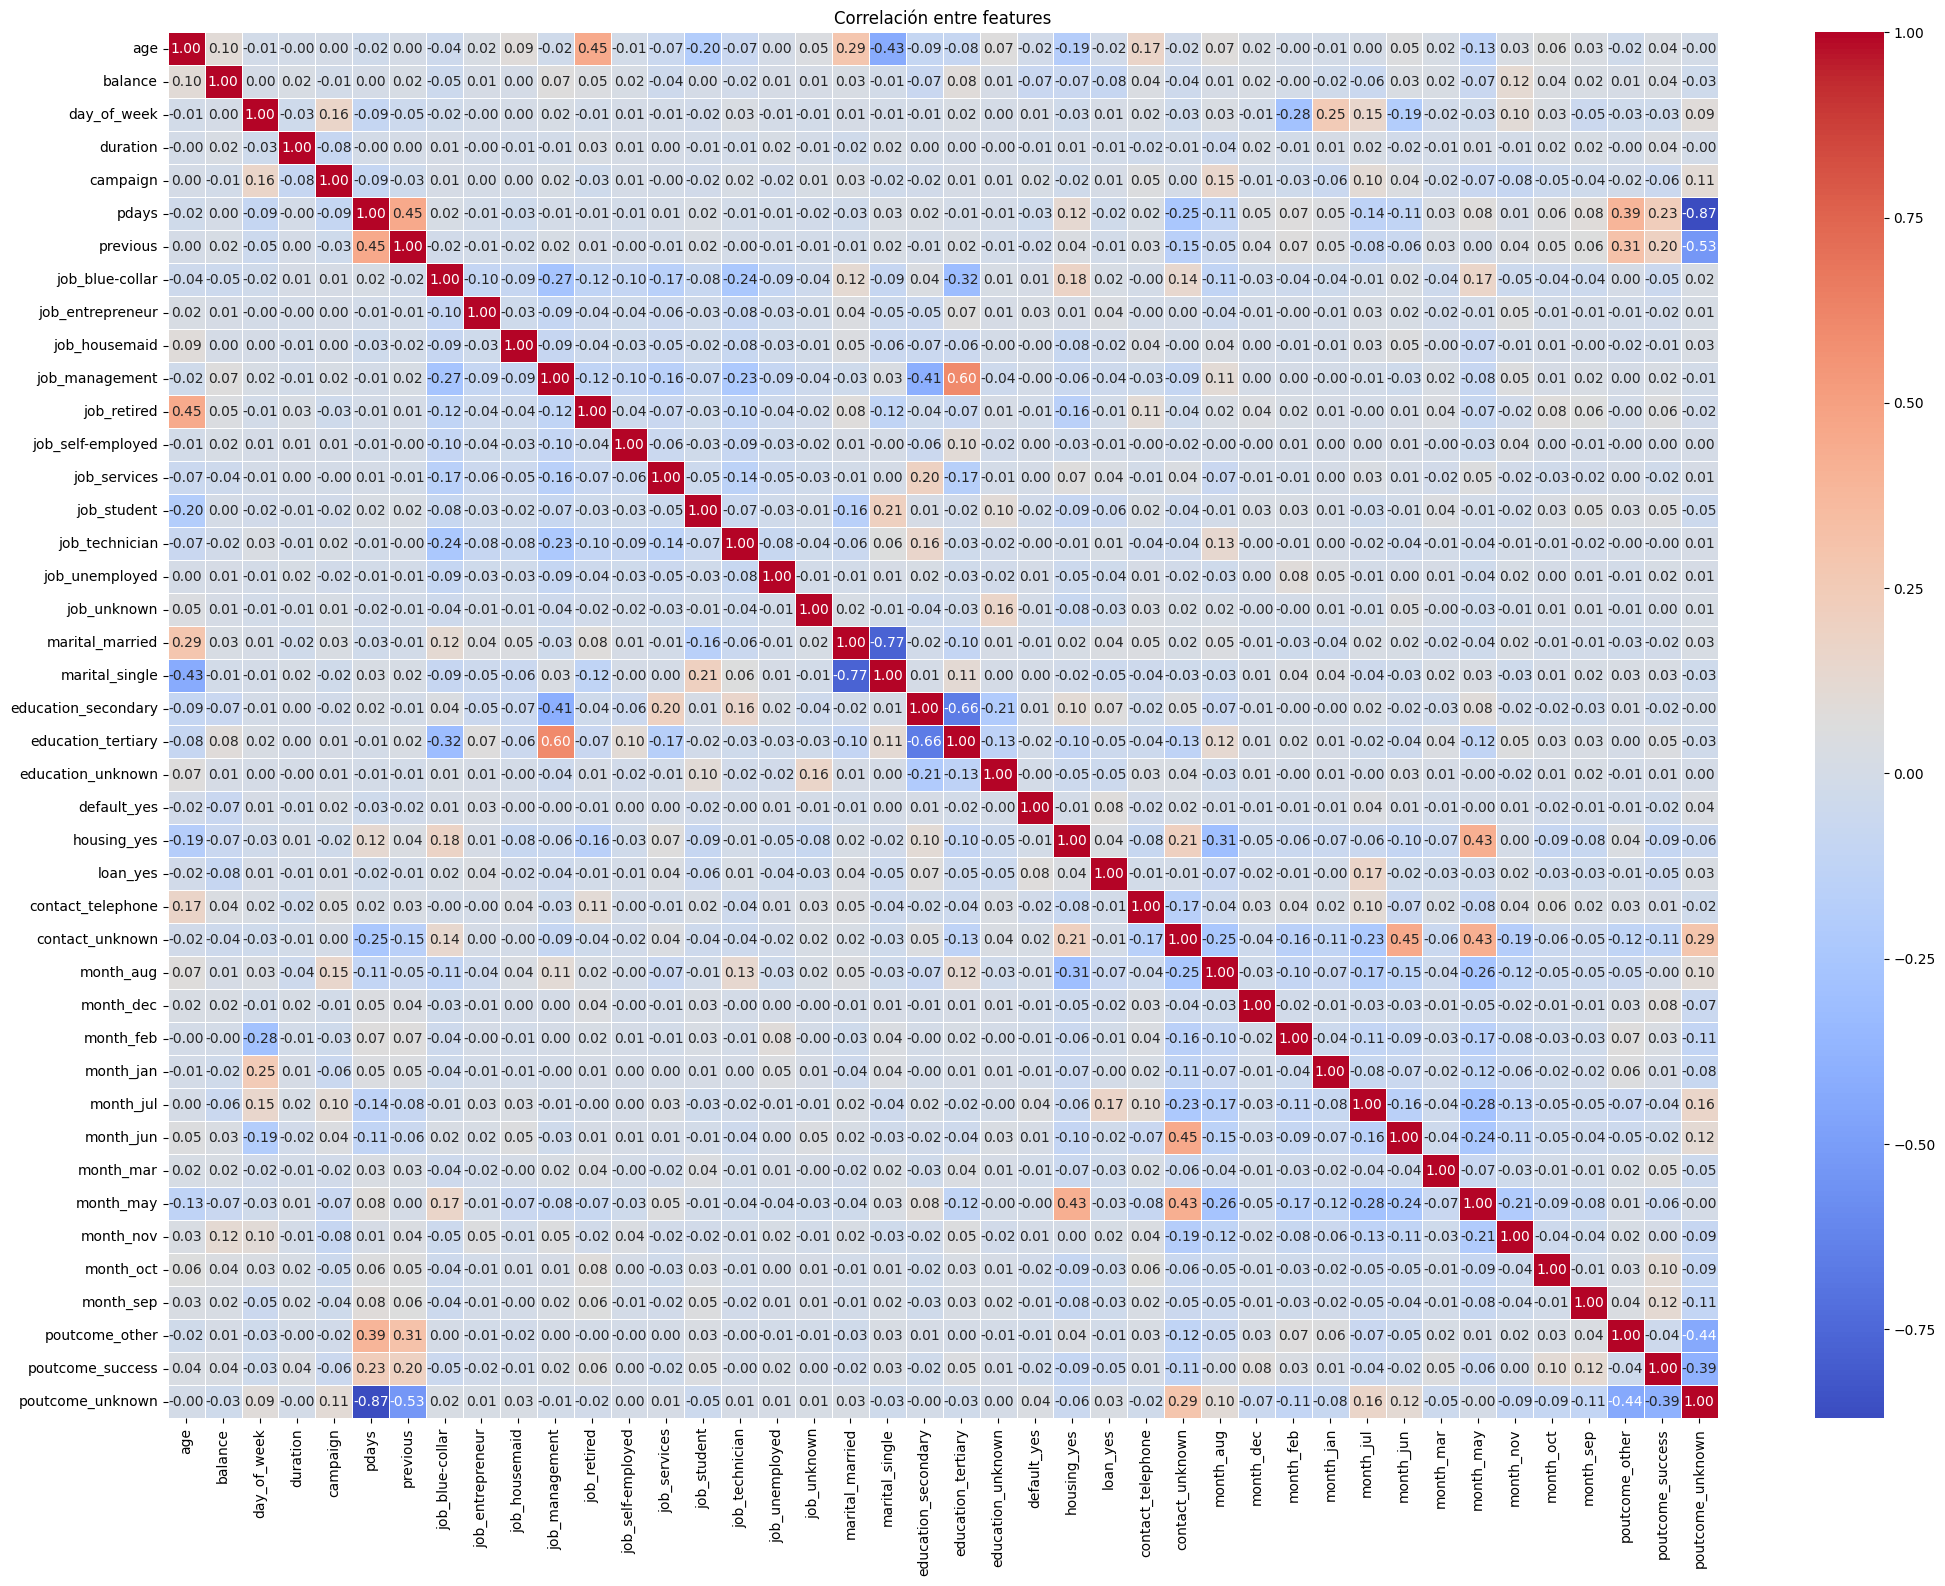

In [11]:
import seaborn as sns
plt.figure(figsize=(25, 18))
sns.heatmap(X.corr(),cmap='coolwarm',annot=True, fmt='.2f', linewidths=0.5)
plt.title('Correlación entre features')
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    shuffle=True,
                                                    stratify=y)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(36168, 42)
(9043, 42)
(36168,)
(9043,)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test) 

print(x_train[:5])
print()
print(x_test[:5])

[[-0.46043404 -0.16441038  1.58212355 -0.45731057 -0.24610373 -0.41090988
  -0.24150867 -0.52564953 -0.18412808 -0.16975054 -0.51195704 -0.229656
  -0.18865458 -0.31939156 -0.1463092   2.22720638 -0.17069641 -0.08069658
  -1.22971136 -0.62788596  0.97396196 -0.64362166 -0.2067031  -0.13496139
  -1.12360121 -0.43760779  3.82228208 -0.63469614  2.50078207 -0.07032651
  -0.24689328 -0.17868053 -0.42516419 -0.36426964 -0.10454094 -0.66378596
  -0.30849688 -0.1289978  -0.1123701  -0.20692116 -0.18564753  0.47153594]
 [-1.58964093  0.89962705 -1.2983841   2.5024925   0.39820171  1.44609608
   2.6645844  -0.52564953 -0.18412808 -0.16975054 -0.51195704 -0.229656
  -0.18865458 -0.31939156  6.83484013 -0.44899297 -0.17069641 -0.08069658
  -1.22971136  1.5926459   0.97396196 -0.64362166 -0.2067031  -0.13496139
  -1.12360121 -0.43760779 -0.26162381 -0.63469614 -0.39987491 -0.07032651
  -0.24689328 -0.17868053 -0.42516419 -0.36426964 -0.10454094 -0.66378596
  -0.30849688 -0.1289978  -0.1123701  -0.

In [14]:
import tensorflow as tf
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(42,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            43 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43 (172.00 B)

 Trainable params: 43 (172.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)

In [16]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 720us/step - accuracy: 0.4689 - loss: 0.9378
Test Loss: 0.9378, Test Accuracy: 0.4689


In [18]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

clases = np.unique(y_train)
pesos = compute_class_weight(class_weight='balanced', classes=clases, y=y_train)
class_weight_dict = dict(zip(clases, pesos))
print(class_weight_dict)
history = model.fit(x_train, 
                    y_train, 
                    epochs=100, 
                    batch_size=32, 
                    validation_split=0.2,
                    callbacks=[early_stop],
                    class_weight=class_weight_dict)

{np.int8(0): np.float64(0.5662397845758838), np.int8(1): np.float64(4.27416686362562)}
Epoch 1/100
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 887us/step - accuracy: 0.5895 - loss: 0.6851 - val_accuracy: 0.6998 - val_loss: 0.5945
Epoch 2/100
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 842us/step - accuracy: 0.7740 - loss: 0.4699 - val_accuracy: 0.8167 - val_loss: 0.4880
Epoch 3/100
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 886us/step - accuracy: 0.8311 - loss: 0.4228 - val_accuracy: 0.8361 - val_loss: 0.4565
Epoch 4/100
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 863us/step - accuracy: 0.8388 - loss: 0.4074 - val_accuracy: 0.8412 - val_loss: 0.4424
Epoch 5/100
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 903us/step - accuracy: 0.8414 - loss: 0.4017 - val_accuracy: 0.8432 - val_loss: 0.4335
Epoch 6/100
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 873us/step - accuracy: 0.8427 - loss: 0.3998 - val_accuracy: 0.8424 - val_loss: 0.4344
Epoch 7/100
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 906us/step - accuracy: 0.8427 - loss: 0.3987 - val_accuracy: 0.8420 - val_loss: 0.4

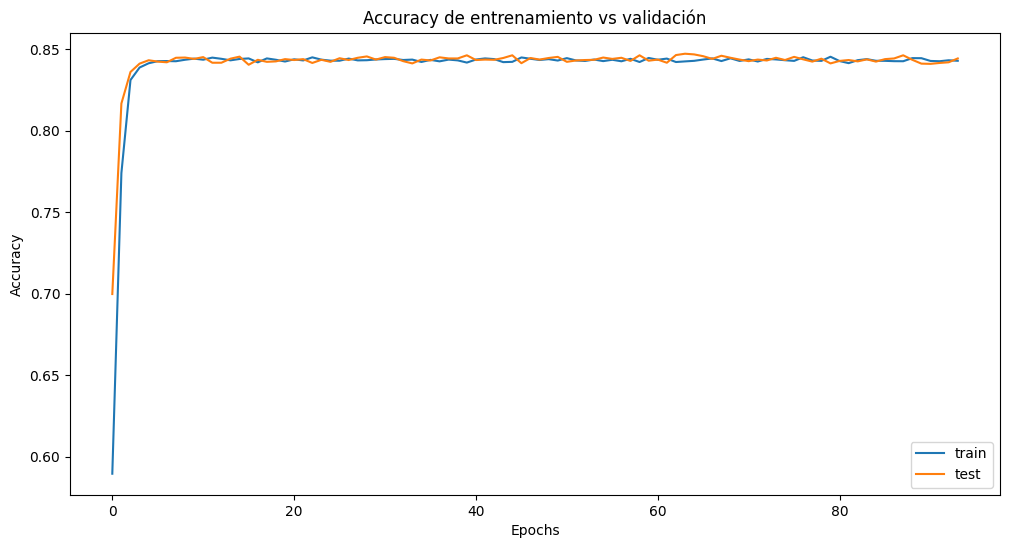

In [19]:
plt.figure(figsize=(12,6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy de entrenamiento vs validación')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train', 'test'])

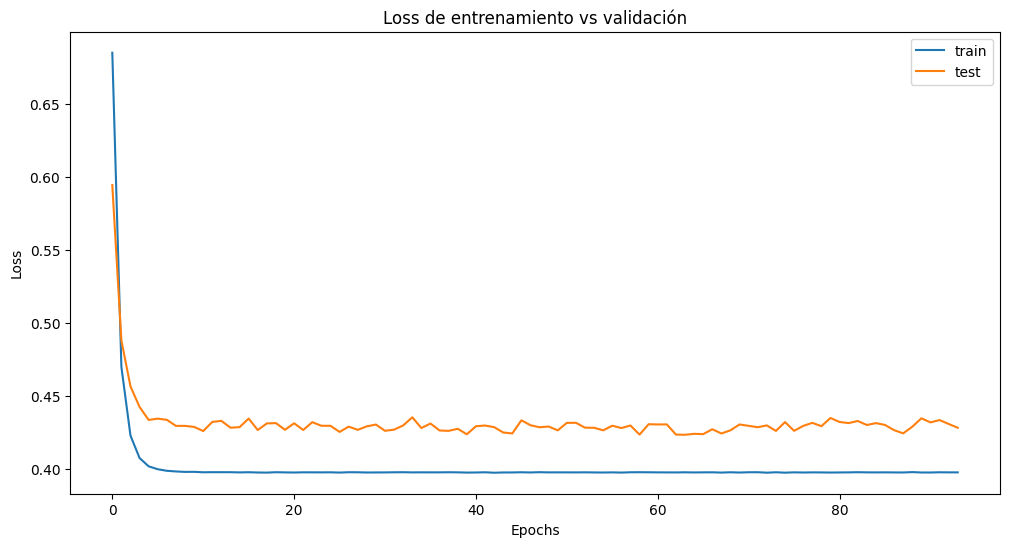

In [20]:
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss de entrenamiento vs validación')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['train', 'test'])

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step


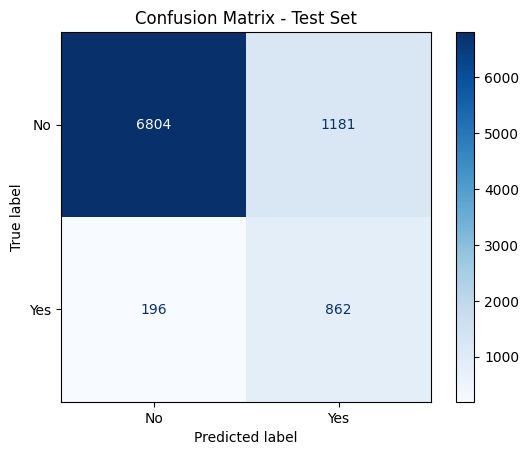

Precision: 0.4219
Recall (Sensitivity): 0.8147
Specificity: 0.8521
F1-Score: 0.5559


In [21]:
# Evaluación final en test set
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score

# Predicciones
y_pred = (model.predict(x_test) > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Test Set')
plt.show()

# Métricas
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
specificity = cm[0,0] / (cm[0,0] + cm[0,1])  # TN / (TN + FP)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")

In [22]:
# Guardar el modelo
model.save('single_neuron_bank_marketing.keras')
print("Modelo guardado exitosamente")

# Cargar el modelo para demostrar que funciona
from tensorflow import keras
loaded_model = keras.models.load_model('single_neuron_bank_marketing.keras')
print("Modelo cargado exitosamente")

# Verificar que funciona
test_loss, test_acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"Modelo cargado - Test Accuracy: {test_acc:.4f}")

Modelo guardado exitosamente
Modelo cargado exitosamente
Modelo cargado - Test Accuracy: 0.8477


In [23]:
from sklearn.decomposition import PCA

# Aplicar PCA
pca = PCA(n_components=0.95)  # 95% de varianza
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

print(f"Características originales: {x_train.shape[1]}")
print(f"Componentes PCA: {x_train_pca.shape[1]}")
print(f"Varianza explicada: {pca.explained_variance_ratio_.sum():.4f}")

Características originales: 42
Componentes PCA: 34
Varianza explicada: 0.9547


In [24]:
model_pca = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(x_train_pca.shape[1],)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model_pca.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_pca = model_pca.fit(x_train_pca, y_train, epochs=100, batch_size=32, 
                            validation_split=0.2, callbacks=[early_stop], 
                            class_weight=class_weight_dict)

Epoch 1/100
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6187 - loss: 0.6450 - val_accuracy: 0.7517 - val_loss: 0.5631
Epoch 2/100
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 886us/step - accuracy: 0.8086 - loss: 0.4510 - val_accuracy: 0.8276 - val_loss: 0.4805
Epoch 3/100
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 907us/step - accuracy: 0.8335 - loss: 0.4215 - val_accuracy: 0.8348 - val_loss: 0.4574
Epoch 4/100
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 902us/step - accuracy: 0.8376 - loss: 0.4147 - val_accuracy: 0.8362 - val_loss: 0.4495
Epoch 5/100
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 888us/step - accuracy: 0.8383 - loss: 0.4129 - val_accuracy: 0.8380 - val_loss: 0.4439
Epoch 6/100
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 934us/step - accuracy: 0.8413 - loss: 0.4124 - val_accuracy: 0.8367 - val_loss: 0.4489
Epoch 7/100
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 884us/step - accuracy: 0.8392 - loss: 0.4122 - val_accuracy: 0.8396 - val_loss: 0.4438
Epoch 8/100
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 887us/step - accuracy: 0.8400 - loss: 0.4

In [25]:
# Tabla comparativa
import pandas as pd

results = pd.DataFrame({
    'Modelo': ['Original (42 features)', 'PCA (X components)'],
    'Accuracy': [accuracy_original, accuracy_pca],
    'Precision': [precision_original, precision_pca],
    'Recall': [recall_original, recall_pca],
    'F1-Score': [f1_original, f1_pca]
})
print(results)

NameError: name 'accuracy_original' is not defined